In [1]:
import pandas as pd
import matplotlib.pyplot as plt

main_df = pd.read_csv(
    "../outputs/makueni_drought_months_and_events_2020_2024.csv"
)

main_df["month"] = pd.to_datetime(main_df["month"])

main_df = main_df.sort_values("month").reset_index(drop=True)

drought_events = pd.read_csv(
    "../outputs/makueni_candidate_drought_events_2020_2024.csv"
)

drought_events["event_start"] = pd.to_datetime(
    drought_events["event_start"]
)

drought_events["event_end"] = pd.to_datetime(
    drought_events["event_end"]
)


drought_events

,drought_event_id,event_start,event_end,duration_months,minimum_rainfall_mm,mean_rainfall_mm,total_rainfall_mm
0,1,2020-08-01,2020-09-01,2,6.516741,6.635028,13.270055
1,2,2021-06-01,2021-06-01,1,2.491424,2.491424,2.491424
2,3,2021-09-01,2021-09-01,1,3.359036,3.359036,3.359036
3,4,2022-06-01,2022-09-01,4,4.881197,5.113040,20.452159
4,5,2023-02-01,2023-02-01,1,3.766772,3.766772,3.766772
5,6,2023-07-01,2023-09-01,3,3.704895,5.084403,15.253208
6,7,2024-06-01,2024-06-01,1,6.949923,6.949923,6.949923
7,8,2024-08-01,2024-09-01,2,3.470424,4.643313,9.286626


In [2]:
BASELINE_MONTHS = 3 # reference value used as benchmark
RESPONSE_MONTHS = 6 # analyzed period after drought event
RECOVERY_RATIO = 0.90 # when do we consider that the vegetation has recovered

In [3]:
results = []

for _, event in drought_events.iterrows():

    event_id = event["drought_event_id"]
    event_start = event["event_start"]
    event_end = event["event_end"]

    baseline_start = (
        event_start
        - pd.DateOffset(months=BASELINE_MONTHS)
    )

    response_end = (
        event_end
        + pd.DateOffset(months=RESPONSE_MONTHS)
    )

    # Months before the drought
    baseline_df = main_df[
        (main_df["month"] >= baseline_start) &
        (main_df["month"] < event_start)
    ].copy()

    # Drought period plus post-drought response window
    response_df = main_df[
        (main_df["month"] >= event_start) &
        (main_df["month"] <= response_end)
    ].copy()

    # Skip events without enough surrounding observations
    if baseline_df.empty or response_df.empty:
        continue

    baseline_ndvi = baseline_df[
        "mean_ndvi_cropland"
    ].mean()

    # Minimum vegetation condition after drought begins
    min_index = response_df[
        "mean_ndvi_cropland"
    ].idxmin()

    min_row = response_df.loc[min_index]

    minimum_ndvi = min_row["mean_ndvi_cropland"]
    minimum_ndvi_month = min_row["month"]

    ndvi_decline = baseline_ndvi - minimum_ndvi # how much did the vegetation declined

    ndvi_decline_pct = (
        ndvi_decline / baseline_ndvi
    ) * 100

    recovery_threshold = (
        baseline_ndvi * RECOVERY_RATIO
    )

    # Search for recovery after the minimum
    after_min = response_df[ # only keep the months that follows the min ndvi level
        response_df["month"] > minimum_ndvi_month
    ].copy()

    recovery_candidates = after_min[ # only keep the months that are within the recovery threshold
        after_min["mean_ndvi_cropland"]
        >= recovery_threshold
    ]

    if not recovery_candidates.empty: # only if there is at least one candidate
        recovery_row = recovery_candidates.iloc[0] # take the first one
        recovery_month = recovery_row["month"]

        recovery_time_months = ( # how long did it take
            (recovery_month.year - minimum_ndvi_month.year) * 12
            + (
                recovery_month.month
                - minimum_ndvi_month.month
            )
        )

        recovered = True # within the response window

    else:
        recovery_month = pd.NaT
        recovery_time_months = pd.NA
        recovered = False

    results.append({
        "drought_event_id": event_id,
        "event_start": event_start,
        "event_end": event_end,
        "duration_months": event["duration_months"],
        "baseline_start": baseline_start,
        "baseline_ndvi": baseline_ndvi,
        "minimum_ndvi": minimum_ndvi,
        "minimum_ndvi_month": minimum_ndvi_month,
        "ndvi_decline": ndvi_decline,
        "ndvi_decline_pct": ndvi_decline_pct,
        "recovery_threshold": recovery_threshold,
        "recovery_month": recovery_month,
        "recovery_time_months": recovery_time_months,
        "recovered_within_window": recovered
    })

In [4]:
response_events_df = pd.DataFrame(results)

response_events_df

,drought_event_id,event_start,event_end,duration_months,baseline_start,baseline_ndvi,minimum_ndvi,minimum_ndvi_month,ndvi_decline,ndvi_decline_pct,recovery_threshold,recovery_month,recovery_time_months,recovered_within_window
0,1,2020-08-01,2020-09-01,2,2020-05-01,0.398765,0.197690,2020-09-01,0.201075,50.424370,0.358889,2020-12-01,3,True
1,2,2021-06-01,2021-06-01,1,2021-03-01,0.252980,0.157697,2021-09-01,0.095284,37.664413,0.227682,2021-12-01,3,True
2,3,2021-09-01,2021-09-01,1,2021-06-01,0.279649,0.157697,2021-09-01,0.121952,43.609028,0.251684,2021-12-01,3,True
3,4,2022-06-01,2022-09-01,4,2022-03-01,0.308229,0.129706,2022-11-01,0.178522,57.918799,0.277406,2022-12-01,1,True
4,5,2023-02-01,2023-02-01,1,2022-11-01,0.359173,0.217837,2023-08-01,0.141336,39.350495,0.323256,NaT,<NA>,False
5,6,2023-07-01,2023-09-01,3,2023-04-01,0.350630,0.170202,2023-10-01,0.180428,51.458210,0.315567,2023-11-01,1,True
6,7,2024-06-01,2024-06-01,1,2024-03-01,0.461690,0.214911,2024-11-01,0.246780,53.451342,0.415521,2024-12-01,1,True
7,8,2024-08-01,2024-09-01,2,2024-05-01,0.430214,0.214911,2024-11-01,0.215304,50.045668,0.387193,2024-12-01,1,True


In [5]:
response_events_df[
    [
        "drought_event_id",
        "event_start",
        "event_end",
        "duration_months",
        "baseline_ndvi",
        "minimum_ndvi",
        "minimum_ndvi_month",
        "ndvi_decline_pct",
        "recovery_month",
        "recovery_time_months",
        "recovered_within_window"
    ]
]

,drought_event_id,event_start,event_end,duration_months,baseline_ndvi,minimum_ndvi,minimum_ndvi_month,ndvi_decline_pct,recovery_month,recovery_time_months,recovered_within_window
0,1,2020-08-01,2020-09-01,2,0.398765,0.197690,2020-09-01,50.424370,2020-12-01,3,True
1,2,2021-06-01,2021-06-01,1,0.252980,0.157697,2021-09-01,37.664413,2021-12-01,3,True
2,3,2021-09-01,2021-09-01,1,0.279649,0.157697,2021-09-01,43.609028,2021-12-01,3,True
3,4,2022-06-01,2022-09-01,4,0.308229,0.129706,2022-11-01,57.918799,2022-12-01,1,True
4,5,2023-02-01,2023-02-01,1,0.359173,0.217837,2023-08-01,39.350495,NaT,<NA>,False
5,6,2023-07-01,2023-09-01,3,0.350630,0.170202,2023-10-01,51.458210,2023-11-01,1,True
6,7,2024-06-01,2024-06-01,1,0.461690,0.214911,2024-11-01,53.451342,2024-12-01,1,True
7,8,2024-08-01,2024-09-01,2,0.430214,0.214911,2024-11-01,50.045668,2024-12-01,1,True


In [6]:
response_events_df[
    response_events_df["ndvi_decline"] <= 0
]

,drought_event_id,event_start,event_end,duration_months,baseline_start,baseline_ndvi,minimum_ndvi,minimum_ndvi_month,ndvi_decline,ndvi_decline_pct,recovery_threshold,recovery_month,recovery_time_months,recovered_within_window


In [7]:
response_events_df.to_csv(
    "../outputs/makueni_vegetation_response_recovery_2020_2024.csv",
    index=False
)

In [15]:
SELECTED_EVENT_ID = 4

selected_result = response_events_df[
    response_events_df["drought_event_id"]
    == SELECTED_EVENT_ID
].iloc[0]

In [16]:
plot_start = selected_result["baseline_start"]

plot_end = (
    selected_result["event_end"]
    + pd.DateOffset(months=RESPONSE_MONTHS)
)

plot_df = main_df[
    (main_df["month"] >= plot_start) &
    (main_df["month"] <= plot_end)
].copy()

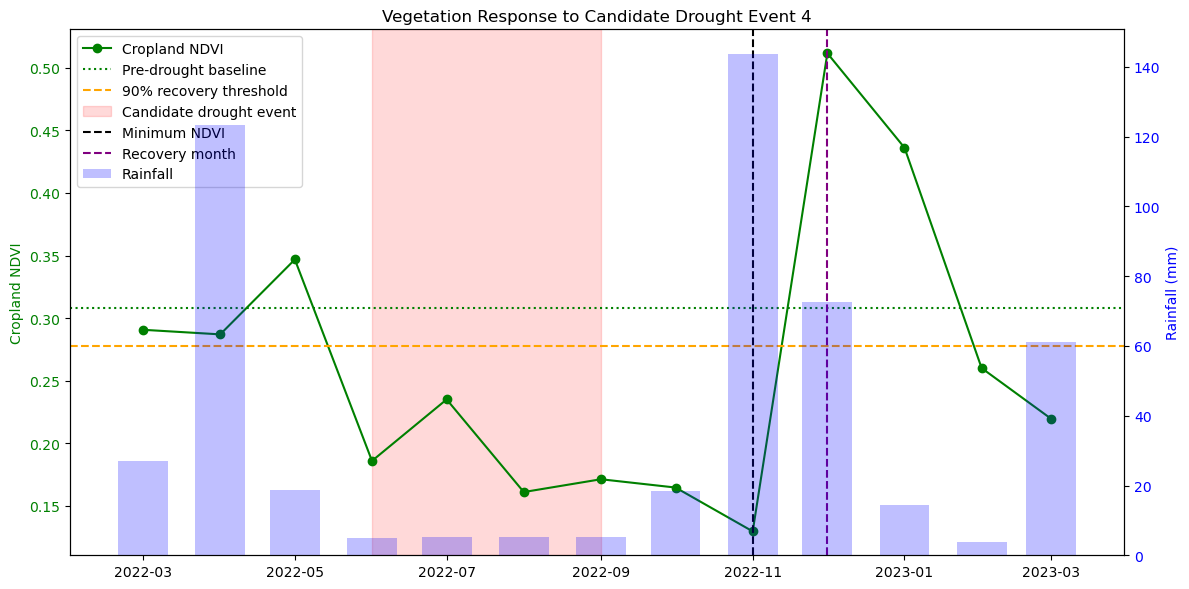

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    plot_df["month"],
    plot_df["mean_ndvi_cropland"],
    color="green",
    marker="o",
    label="Cropland NDVI"
)

ax1.axhline(
    selected_result["baseline_ndvi"],
    color="green",
    linestyle=":",
    label="Pre-drought baseline"
)

ax1.axhline(
    selected_result["recovery_threshold"],
    color="orange",
    linestyle="--",
    label="90% recovery threshold"
)

ax1.axvspan(
    selected_result["event_start"],
    selected_result["event_end"],
    color="red",
    alpha=0.15,
    label="Candidate drought event"
)

ax1.axvline(
    selected_result["minimum_ndvi_month"],
    color="black",
    linestyle="--",
    label="Minimum NDVI"
)

if pd.notna(selected_result["recovery_month"]):
    ax1.axvline(
        selected_result["recovery_month"],
        color="purple",
        linestyle="--",
        label="Recovery month"
    )

ax1.set_ylabel("Cropland NDVI", color="green")
ax1.tick_params(axis="y", labelcolor="green")

ax2 = ax1.twinx()

ax2.bar(
    plot_df["month"],
    plot_df["rainfall_mm"],
    color="blue",
    alpha=0.25,
    width=20,
    label="Rainfall"
)

ax2.set_ylabel("Rainfall (mm)", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

ax1.set_title(
    f"Vegetation Response to Candidate Drought Event "
    f"{SELECTED_EVENT_ID}"
)

fig.tight_layout()

fig.savefig(
    f"../docs/images/"
    f"makueni_drought_event_{SELECTED_EVENT_ID}_response.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()